# 02 — Feature Engineering

Builds the two feature tables used by every downstream model:

1. **Demand panel** — `restaurant × zone × 30-min bucket` grid with temporal,
   lag, rolling, and historical-aggregate features, and multi-horizon targets.
2. **ETA feature table** — order-level features for delivery-time prediction.

The actual feature-construction logic lives in `src/features/build_features.py`
(not duplicated here) so it is unit-tested and reusable from `app/inference.py`.
This notebook calls it, then inspects and visualizes the result.

**Leakage discipline** (see `tests/test_feature_leakage.py` for enforcement):
every lag/rolling/historical feature is computed on a series `shift(1)`ed
before any aggregation, so bucket *t*'s own value can never appear in its own
features.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.features.build_features import build_demand_features, build_eta_features
from src.utils.config import load_config
import pathlib

sns.set_theme(style="whitegrid")
cfg = load_config()
raw_dir = pathlib.Path("../data/raw")

In [2]:
%%time
demand_panel = build_demand_features(raw_dir, cfg)
print(demand_panel.shape)
demand_panel.to_parquet("../data/processed/demand_timeseries.parquet", index=False)
demand_panel.head(3)

(648000, 43)


CPU times: user 1.92 s, sys: 340 ms, total: 2.26 s
Wall time: 1.6 s


,restaurant_id,zone_id,bucket_ts,order_count,avg_basket_value,avg_distance_km,hour,dow,is_weekend,month,...,restaurant_hist_volatility,zone_demand_prev_bucket,rain_mm,weather_condition,traffic_multiplier,target_30m,target_1h,target_2h,target_6h,target_1d
0,0,8,2026-05-01 00:00:00,1,554.24,1.417,0,4,0,5,...,NaN,NaN,0.0,Clear,0.793,0.0,0.0,0.0,0.0,0.0
1,0,8,2026-05-01 00:30:00,0,NaN,NaN,0,4,0,5,...,NaN,6.0,0.0,Clear,0.793,0.0,1.0,1.0,1.0,1.0
2,0,8,2026-05-01 01:00:00,0,NaN,NaN,1,4,0,5,...,0.707107,3.0,0.0,Clear,0.630,1.0,0.0,1.0,0.0,0.0


In [3]:
%%time
eta_features = build_eta_features(raw_dir, cfg)
print(eta_features.shape)
eta_features.to_parquet("../data/processed/eta_features.parquet", index=False)
eta_features.head(3)

(3007749, 28)


CPU times: user 3.57 s, sys: 925 ms, total: 4.5 s
Wall time: 3.8 s


,order_id,customer_id,order_timestamp,restaurant_id,zone_id,n_items,basket_value_inr,distance_km,prep_time_min,travel_time_min,...,rating,hour,dow,is_weekend,is_peak_hour,hour_sin,hour_cos,restaurant_hist_avg_prep_time,restaurant_hist_avg_eta,restaurant_order_sequence_num
0,1446818,22505,2026-05-01 00:01:28,65,9,4,1253.88,3.238,11.62,8.45,...,3.86,0,4,0,0,0.0,1.0,NaN,NaN,0
1,3032202,19370,2026-05-01 00:02:28,149,7,7,1568.96,2.424,12.94,6.50,...,3.16,0,4,0,0,0.0,1.0,NaN,NaN,0
2,2127652,25171,2026-05-01 00:02:38,103,10,1,82.62,1.891,18.21,3.39,...,3.90,0,4,0,0,0.0,1.0,NaN,NaN,0


## Feature catalogue

In [4]:
feature_groups = {
    "temporal": ["hour", "dow", "is_weekend", "month", "is_lunch_peak", "is_dinner_peak",
                 "hour_sin", "hour_cos", "dow_sin", "dow_cos"],
    "lag": [c for c in demand_panel.columns if c.startswith("lag_")],
    "rolling": [c for c in demand_panel.columns if c.startswith("roll_") or c.startswith("ewm_")],
    "restaurant/zone history": ["restaurant_hist_avg_demand", "restaurant_hist_volatility",
                                 "zone_demand_prev_bucket"],
    "external": ["rain_mm", "weather_condition", "traffic_multiplier"],
    "targets (multi-horizon)": [c for c in demand_panel.columns if c.startswith("target_")],
}
for group, cols in feature_groups.items():
    print(f"{group}: {cols}")

temporal: ['hour', 'dow', 'is_weekend', 'month', 'is_lunch_peak', 'is_dinner_peak', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
lag: ['lag_30m', 'lag_1h', 'lag_2h', 'lag_1d', 'lag_7d']
rolling: ['roll_mean_2h', 'roll_std_2h', 'roll_max_2h', 'roll_mean_8h', 'roll_std_8h', 'roll_max_8h', 'roll_mean_1d', 'roll_std_1d', 'roll_max_1d', 'ewm_mean_short']
restaurant/zone history: ['restaurant_hist_avg_demand', 'restaurant_hist_volatility', 'zone_demand_prev_bucket']
external: ['rain_mm', 'weather_condition', 'traffic_multiplier']
targets (multi-horizon): ['target_30m', 'target_1h', 'target_2h', 'target_6h', 'target_1d']


## Sanity check: leakage-safety, visually

Plot one restaurant's actual `order_count` series against its `lag_30m` and
`roll_mean_8h` features. The lag/rolling series should visibly trail the
actual series (never lead it, never touch it at the same timestamp).

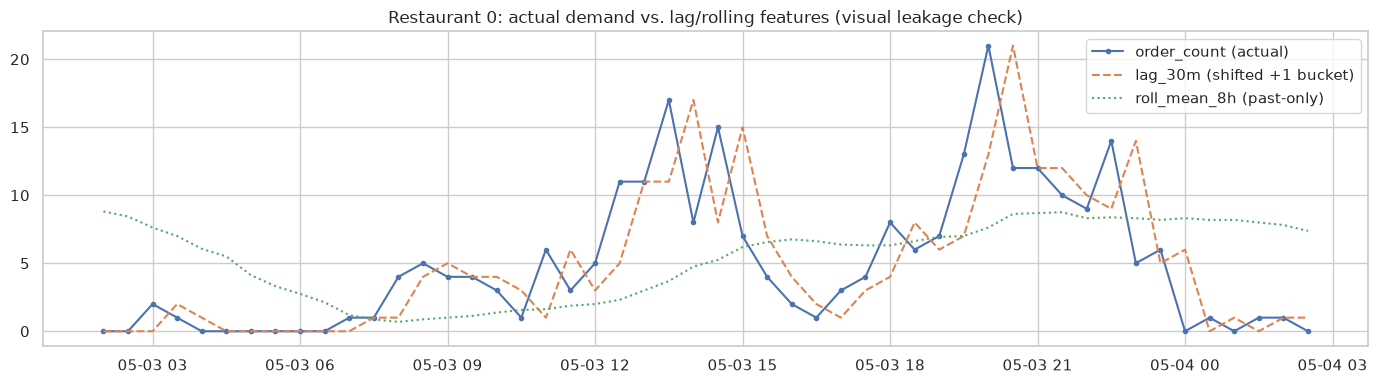

In [5]:
sample_rest = demand_panel["restaurant_id"].iloc[0]
sample = demand_panel[demand_panel["restaurant_id"] == sample_rest].sort_values("bucket_ts").iloc[100:150]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample["bucket_ts"], sample["order_count"], label="order_count (actual)", marker="o", ms=3)
ax.plot(sample["bucket_ts"], sample["lag_30m"], label="lag_30m (shifted +1 bucket)", linestyle="--")
ax.plot(sample["bucket_ts"], sample["roll_mean_8h"], label="roll_mean_8h (past-only)", linestyle=":")
ax.set_title(f"Restaurant {sample_rest}: actual demand vs. lag/rolling features (visual leakage check)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/02_leakage_visual_check.png", dpi=150)
plt.show()

## Missingness introduced by feature engineering

In [6]:
# Early buckets of each restaurant's series have no history yet -> NaN lag/rolling features.
# This is EXPECTED (there is no data before the start of the simulation) and these rows
# are dropped before model training (see src/forecasting/train_demand_models.py::_prepare_xy).
na_frac = demand_panel[[c for c in demand_panel.columns if c.startswith(("lag_", "roll_", "restaurant_hist"))]].isna().mean()
print(na_frac.sort_values(ascending=False))

lag_7d                        0.077778
lag_1d                        0.011111
lag_2h                        0.000926
lag_1h                        0.000463
roll_std_2h                   0.000463
restaurant_hist_volatility    0.000463
roll_std_1d                   0.000463
roll_std_8h                   0.000463
roll_max_2h                   0.000231
roll_mean_2h                  0.000231
lag_30m                       0.000231
roll_mean_8h                  0.000231
roll_mean_1d                  0.000231
roll_max_8h                   0.000231
roll_max_1d                   0.000231
restaurant_hist_avg_demand    0.000231
dtype: float64


## Summary

- Demand panel: **648,000 rows** (150 restaurants × 12 zones × 30-min buckets over 90 days),
  43 columns including 5 forecast targets (30m / 1h / 2h / 6h / next-day).
- ETA table: ~3.0M order-level rows, 28 columns.
- Visual and unit-test verification confirms no future information leaks into
  any lag/rolling/historical feature.
- Next: `03_demand_forecasting.ipynb` trains and compares baseline and ML
  models on the demand panel.